
# Modelo operacional de peak: modelo completo LASSO vs modelo simple

- Completo: todas las variables relevantes según LASSO.
- Simple: las 5 variables más relevantes según LASSO.


In [17]:

import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV, LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

SEED = 42
np.random.seed(SEED)

ARTIFACT_DIR = "artifacts_peak_operational_19h_no_std_lasso_selected"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)



## 1. Carga del dataset horario


In [18]:

CSV_HOURLY = "data_hourly_agg.csv"

TIME_COL = "instante"
TARGET_COL = "HS30_min"
IRR_EVENT_COL = "evento_riego_max"
IRR_LITERS_COL = "litros_intervalo_sum"

required_cols = [TIME_COL, TARGET_COL, IRR_EVENT_COL, IRR_LITERS_COL]

data = pd.read_csv(CSV_HOURLY)

missing = [c for c in required_cols if c not in data.columns]
if missing:
    raise ValueError(
        f"Faltan columnas obligatorias en {CSV_HOURLY}: {missing}\n"
        f"Columnas disponibles: {data.columns.tolist()}"
    )

data[TIME_COL] = pd.to_datetime(data[TIME_COL])
data = data.sort_values(TIME_COL).reset_index(drop=True)

print("Dimensiones:", data.shape)
print("Rango temporal:", data[TIME_COL].min(), "->", data[TIME_COL].max())
print("Columnas disponibles:")
print(data.columns.tolist())

display(data.head())


Dimensiones: (45457, 16)
Rango temporal: 2018-07-10 00:00:00 -> 2023-09-16 00:00:00
Columnas disponibles:
['instante', 'HS10_mean', 'HS20_mean', 'HS30_mean', 'HS30_min', 'HS40_mean', 'HS50_mean', 'HS60_mean', 'TS30_mean', 'dendrometro_mean', 'litros_arbol_last', 'litros_intervalo_sum', 'evento_riego_max', 'TA_mean', 'HA_mean', 'radiacion_mean']


,instante,HS10_mean,HS20_mean,HS30_mean,HS30_min,HS40_mean,HS50_mean,HS60_mean,TS30_mean,dendrometro_mean,litros_arbol_last,litros_intervalo_sum,evento_riego_max,TA_mean,HA_mean,radiacion_mean
0,2018-07-10 00:00:00,0.838623,0.835938,0.823721,0.823615,0.772187,0.851173,0.765728,28.2,38.733403,288.8,0.0,0.0,21.173333,78.583333,0.000000
1,2018-07-10 01:00:00,0.837167,0.835225,0.823388,0.823200,0.771916,0.850721,0.765309,28.2,38.735932,288.8,0.0,0.0,20.878333,78.666667,0.000000
2,2018-07-10 02:00:00,0.835618,0.834313,0.822934,0.822700,0.771497,0.850346,0.764886,28.2,38.737864,288.8,0.0,0.0,20.746667,77.800000,0.000000
3,2018-07-10 03:00:00,0.834118,0.833427,0.822334,0.822000,0.771086,0.849906,0.764475,28.2,38.740000,288.8,0.0,0.0,20.585000,78.650000,0.000000
4,2018-07-10 04:00:00,0.832634,0.832703,0.821752,0.821501,0.770690,0.849608,0.764169,28.2,38.740573,288.8,0.0,0.0,20.400000,80.366667,0.498333



## 2. Detección de eventos de riego

Se consideran eventos de riego las secuencias consecutivas en las que:

- `evento_riego_max > 0`, o
- `litros_intervalo_sum > 0`.


In [19]:

irrigation_mask = (
    (data[IRR_EVENT_COL].fillna(0) > 0) |
    (data[IRR_LITERS_COL].fillna(0) > 0)
)

runs = []
in_run = False

for idx, is_irrigating in enumerate(irrigation_mask.values):
    if is_irrigating and not in_run:
        start_idx = idx
        in_run = True

    is_last = idx == len(irrigation_mask) - 1

    if in_run and ((not is_irrigating) or is_last):
        end_idx = idx - 1 if not is_irrigating else idx
        runs.append((start_idx, end_idx))
        in_run = False

irrigation_runs = pd.DataFrame({
    "event_id": range(len(runs)),
    "start_idx": [r[0] for r in runs],
    "end_idx": [r[1] for r in runs]
})

irrigation_runs["start"] = irrigation_runs["start_idx"].map(data[TIME_COL])
irrigation_runs["end"] = irrigation_runs["end_idx"].map(data[TIME_COL])

print("Eventos de riego detectados:", len(irrigation_runs))
display(irrigation_runs.head())


Eventos de riego detectados: 819


,event_id,start_idx,end_idx,start,end
0,0,8,11,2018-07-10 08:00:00,2018-07-10 11:00:00
1,1,32,35,2018-07-11 08:00:00,2018-07-11 11:00:00
2,2,56,59,2018-07-12 08:00:00,2018-07-12 11:00:00
3,3,80,83,2018-07-13 08:00:00,2018-07-13 11:00:00
4,4,104,107,2018-07-14 08:00:00,2018-07-14 11:00:00



## 3. Construcción del dataset operacional


In [20]:

PEAK_SEARCH_EXTRA_HOURS = 6
MIN_DURATION_HOURS = 4
MAX_DURATION_HOURS = 72
MIN_AMPLITUDE = 0.01

BASE_HISTORICAL_FEATURES = [
    "TA_mean",
    "HA_mean",
    "radiacion_mean",
    "HS10_mean",
    "HS20_mean",
    "HS30_mean",
    "TS30_mean",
    "litros_intervalo_sum"
]

BASE_HISTORICAL_FEATURES = [c for c in BASE_HISTORICAL_FEATURES if c in data.columns]

def get_agronomic_start(ts):
    """
    Devuelve el inicio del día agronómico correspondiente a un timestamp.
    El día agronómico va de 19:00 a 19:00.
    """
    ts = pd.Timestamp(ts)
    candidate = ts.normalize() + pd.Timedelta(hours=19)
    if ts.hour < 19:
        candidate = candidate - pd.Timedelta(days=1)
    return candidate

rows = []

for i, row in irrigation_runs.iterrows():
    event_start = row["start"]
    event_end = row["end"]

    if i < len(irrigation_runs) - 1:
        next_event_start = irrigation_runs.loc[i + 1, "start"]
    else:
        next_event_start = data[TIME_COL].max() + pd.Timedelta(hours=1)

    peak_window = data[
        (data[TIME_COL] >= event_start) &
        (data[TIME_COL] <= event_end + pd.Timedelta(hours=PEAK_SEARCH_EXTRA_HOURS))
    ].copy()

    if peak_window.empty:
        continue

    peak_idx = peak_window[TARGET_COL].idxmax()
    peak_time = data.loc[peak_idx, TIME_COL]
    peak_value = float(data.loc[peak_idx, TARGET_COL])

    desc_window = data[
        (data[TIME_COL] >= peak_time) &
        (data[TIME_COL] < next_event_start)
    ].copy()

    if desc_window.empty:
        continue

    duration_h = (desc_window[TIME_COL].max() - desc_window[TIME_COL].min()).total_seconds() / 3600.0

    if duration_h < MIN_DURATION_HOURS or duration_h > MAX_DURATION_HOURS:
        continue

    min_idx = desc_window[TARGET_COL].idxmin()
    min_time = data.loc[min_idx, TIME_COL]
    min_value = float(data.loc[min_idx, TARGET_COL])

    amplitude = peak_value - min_value

    if amplitude < MIN_AMPLITUDE:
        continue

    inference_time = get_agronomic_start(event_start)

    hist_24h = data[
        (data[TIME_COL] > inference_time - pd.Timedelta(hours=24)) &
        (data[TIME_COL] <= inference_time)
    ].copy()

    hist_48h = data[
        (data[TIME_COL] > inference_time - pd.Timedelta(hours=48)) &
        (data[TIME_COL] <= inference_time)
    ].copy()

    future_24h = data[
        (data[TIME_COL] > inference_time) &
        (data[TIME_COL] <= inference_time + pd.Timedelta(hours=24))
    ].copy()

    # Misma tolerancia que el notebook corregido base.
    if len(hist_24h) < 20 or len(hist_48h) < 44 or len(future_24h) < 20:
        continue

    event_row = {
        "event_id": int(row["event_id"]),
        "event_start": event_start,
        "event_end": event_end,
        "inference_time": inference_time,
        "peak_time": peak_time,
        "min_time": min_time,
        "peak_value": peak_value,
        "HS30_min_target": min_value,
        "irrigation_hour": int(pd.Timestamp(event_start).hour),
        "duration_h_real": duration_h,
        "amplitude": amplitude,
        "liters_event_sum": float(data.loc[row["start_idx"]:row["end_idx"], IRR_LITERS_COL].sum())
    }

    # Sin desviación estándar: solo mean, min y max.
    for feature in BASE_HISTORICAL_FEATURES:
        for label, window_df in [("24h", hist_24h), ("48h", hist_48h)]:
            event_row[f"{feature}_hist_{label}_mean"] = float(window_df[feature].mean())
            event_row[f"{feature}_hist_{label}_min"] = float(window_df[feature].min())
            event_row[f"{feature}_hist_{label}_max"] = float(window_df[feature].max())

    if "TA_mean" in data.columns:
        event_row["TA_mean_future_24h_mean"] = float(future_24h["TA_mean"].mean())
        event_row["TA_mean_future_24h_min"] = float(future_24h["TA_mean"].min())
        event_row["TA_mean_future_24h_max"] = float(future_24h["TA_mean"].max())

    rows.append(event_row)

event_df = pd.DataFrame(rows)

print("Eventos válidos para entrenamiento:", event_df.shape)
display(event_df.head())


Eventos válidos para entrenamiento: (715, 63)


,event_id,event_start,event_end,inference_time,peak_time,min_time,peak_value,HS30_min_target,irrigation_hour,duration_h_real,amplitude,liters_event_sum,TA_mean_hist_24h_mean,TA_mean_hist_24h_min,TA_mean_hist_24h_max,TA_mean_hist_48h_mean,TA_mean_hist_48h_min,TA_mean_hist_48h_max,HA_mean_hist_24h_mean,HA_mean_hist_24h_min,HA_mean_hist_24h_max,HA_mean_hist_48h_mean,HA_mean_hist_48h_min,HA_mean_hist_48h_max,radiacion_mean_hist_24h_mean,radiacion_mean_hist_24h_min,radiacion_mean_hist_24h_max,radiacion_mean_hist_48h_mean,radiacion_mean_hist_48h_min,radiacion_mean_hist_48h_max,HS10_mean_hist_24h_mean,HS10_mean_hist_24h_min,HS10_mean_hist_24h_max,HS10_mean_hist_48h_mean,HS10_mean_hist_48h_min,HS10_mean_hist_48h_max,HS20_mean_hist_24h_mean,HS20_mean_hist_24h_min,HS20_mean_hist_24h_max,HS20_mean_hist_48h_mean,HS20_mean_hist_48h_min,HS20_mean_hist_48h_max,HS30_mean_hist_24h_mean,HS30_mean_hist_24h_min,HS30_mean_hist_24h_max,HS30_mean_hist_48h_mean,HS30_mean_hist_48h_min,HS30_mean_hist_48h_max,TS30_mean_hist_24h_mean,TS30_mean_hist_24h_min,TS30_mean_hist_24h_max,TS30_mean_hist_48h_mean,TS30_mean_hist_48h_min,TS30_mean_hist_48h_max,litros_intervalo_sum_hist_24h_mean,litros_intervalo_sum_hist_24h_min,litros_intervalo_sum_hist_24h_max,litros_intervalo_sum_hist_48h_mean,litros_intervalo_sum_hist_48h_min,litros_intervalo_sum_hist_48h_max,TA_mean_future_24h_mean,TA_mean_future_24h_min,TA_mean_future_24h_max
0,2,2018-07-12 08:00:00,2018-07-12 11:00:00,2018-07-11 19:00:00,2018-07-12 10:00:00,2018-07-13 07:00:00,0.858600,0.816740,8,21.0,0.041860,45.8,26.294583,20.801667,32.015000,26.633371,20.351667,33.850000,70.999653,49.590000,89.516667,66.396023,34.291667,89.516667,296.830764,0.0,842.666667,328.584848,0.0,860.000000,0.849760,0.833382,0.871730,0.849352,0.828519,0.877807,0.844495,0.831848,0.871033,0.844777,0.829779,0.876974,0.831693,0.818613,0.863882,0.832249,0.818613,0.866161,28.230375,28.0,28.4,28.054476,27.4,28.4,1.858333,0.0,15.0,1.990909,0.0,15.4,26.438750,20.971667,33.468333
1,3,2018-07-13 08:00:00,2018-07-13 11:00:00,2018-07-12 19:00:00,2018-07-13 10:00:00,2018-07-14 07:00:00,0.858443,0.813786,8,21.0,0.044657,44.2,26.438750,20.971667,33.468333,26.366667,20.801667,33.468333,70.430694,39.851667,91.150000,70.715174,39.851667,91.150000,301.032292,0.0,858.500000,298.931528,0.0,858.500000,0.846502,0.831626,0.868674,0.848022,0.831626,0.871730,0.841716,0.830726,0.871027,0.843013,0.830726,0.871033,0.829241,0.819334,0.860041,0.830385,0.818613,0.863882,28.397260,28.0,28.6,28.319380,28.0,28.6,1.908333,0.0,16.0,1.883333,0.0,16.0,27.108125,23.381667,31.983333
2,4,2018-07-14 08:00:00,2018-07-14 11:00:00,2018-07-13 19:00:00,2018-07-14 10:00:00,2018-07-15 07:00:00,0.854546,0.809013,8,21.0,0.045533,45.4,27.108125,23.381667,31.983333,26.773438,20.971667,33.468333,69.265417,44.673333,89.633333,69.848056,39.851667,91.150000,267.702431,0.0,749.166667,284.367361,0.0,858.500000,0.844967,0.832999,0.871897,0.845735,0.831626,0.871897,0.840211,0.830697,0.872982,0.840963,0.830697,0.872982,0.827075,0.817012,0.859865,0.828158,0.817012,0.860041,28.640358,28.4,29.0,28.518809,28.0,29.0,1.841667,0.0,15.0,1.875000,0.0,16.0,27.779722,21.836667,34.601667
3,5,2018-07-15 08:00:00,2018-07-15 11:00:00,2018-07-14 19:00:00,2018-07-15 10:00:00,2018-07-16 07:00:00,0.851669,0.802351,8,21.0,0.049318,45.0,27.779722,21.836667,34.601667,27.443924,21.836667,34.601667,65.261319,41.380000,85.883333,67.263368,41.380000,89.633333,296.245208,0.0,830.333333,281.973819,0.0,830.333333,0.839391,0.824560,0.862439,0.842179,0.824560,0.871897,0.835826,0.824542,0.867142,0.838018,0.824542,0.872982,0.823906,0.813991,0.855232,0.825490,0.813991,0.859865,28.668110,28.2,29.0,28.654234,28.2,29.0,1.891667,0.0,15.8,1.866667,0.0,15.8,27.510347,22.006667,35.888333
4,6,2018-07-16 08:00:00,2018-07-16 11:00:00,2018-07-15 19:00:00,2018-07-16 11:00:00,2018-07-17 08:00:00,0.847959,0.803199,8,22.0,0.044760,47.4,27.510347,22.006667,35.888333,27.645035,21.836667,35.888333,60.318056,27.865000,84.383333,62.789687,27.865000,8


## 4. Predictores candidatos y partición train/test

Primero se construye el conjunto completo de variables candidatas. Después se aplica LASSO sobre el conjunto de entrenamiento para seleccionar las variables relevantes.


In [21]:

if event_df.empty:
    raise ValueError("No se han generado eventos válidos. Revisa las reglas de detección de riego o los nombres de columnas.")

non_feature_cols = [
    "event_id",
    "event_start",
    "event_end",
    "inference_time",
    "peak_time",
    "min_time",
    "peak_value",
    "duration_h_real",
    "amplitude",
    "liters_event_sum"
]

candidate_feature_cols = [c for c in event_df.columns if c not in non_feature_cols]

X_candidates = event_df[candidate_feature_cols].copy()
y = event_df["peak_value"].copy()

X_train_candidates, X_test_candidates, y_train, y_test = train_test_split(
    X_candidates,
    y,
    test_size=0.20,
    random_state=SEED
)

print("N eventos:", len(event_df))
print("N variables candidatas antes de LASSO:", len(candidate_feature_cols))
print("Train candidatos:", X_train_candidates.shape)
print("Test candidatos:", X_test_candidates.shape)

display(X_train_candidates.head())


N eventos: 715
N variables candidatas antes de LASSO: 53
Train candidatos: (572, 53)
Test candidatos: (143, 53)


,HS30_min_target,irrigation_hour,TA_mean_hist_24h_mean,TA_mean_hist_24h_min,TA_mean_hist_24h_max,TA_mean_hist_48h_mean,TA_mean_hist_48h_min,TA_mean_hist_48h_max,HA_mean_hist_24h_mean,HA_mean_hist_24h_min,HA_mean_hist_24h_max,HA_mean_hist_48h_mean,HA_mean_hist_48h_min,HA_mean_hist_48h_max,radiacion_mean_hist_24h_mean,radiacion_mean_hist_24h_min,radiacion_mean_hist_24h_max,radiacion_mean_hist_48h_mean,radiacion_mean_hist_48h_min,radiacion_mean_hist_48h_max,HS10_mean_hist_24h_mean,HS10_mean_hist_24h_min,HS10_mean_hist_24h_max,HS10_mean_hist_48h_mean,HS10_mean_hist_48h_min,HS10_mean_hist_48h_max,HS20_mean_hist_24h_mean,HS20_mean_hist_24h_min,HS20_mean_hist_24h_max,HS20_mean_hist_48h_mean,HS20_mean_hist_48h_min,HS20_mean_hist_48h_max,HS30_mean_hist_24h_mean,HS30_mean_hist_24h_min,HS30_mean_hist_24h_max,HS30_mean_hist_48h_mean,HS30_mean_hist_48h_min,HS30_mean_hist_48h_max,TS30_mean_hist_24h_mean,TS30_mean_hist_24h_min,TS30_mean_hist_24h_max,TS30_mean_hist_48h_mean,TS30_mean_hist_48h_min,TS30_mean_hist_48h_max,litros_intervalo_sum_hist_24h_mean,litros_intervalo_sum_hist_24h_min,litros_intervalo_sum_hist_24h_max,litros_intervalo_sum_hist_48h_mean,litros_intervalo_sum_hist_48h_min,litros_intervalo_sum_hist_48h_max,TA_mean_future_24h_mean,TA_mean_future_24h_min,TA_mean_future_24h_max
264,0.751598,9,16.869167,11.780000,22.305000,17.784722,11.780000,22.885000,73.072569,46.665000,90.083333,71.615069,46.608333,94.050000,210.950486,0.0,786.000000,268.750938,0.0,922.333333,0.808324,0.792673,0.834934,0.799334,0.764954,0.834934,0.789890,0.779039,0.820549,0.785029,0.764362,0.825067,0.760956,0.750868,0.804030,0.758444,0.742482,0.807076,20.697364,20.400000,21.000000,20.654583,20.400000,21.000000,0.716667,0.0,7.2,0.800000,0.0,10.8,18.117153,15.603333,21.983333
56,0.805862,9,25.408819,21.478333,29.726667,24.726667,19.725000,29.726667,77.126944,59.271667,90.500000,76.295625,58.241667,90.500000,178.107083,0.0,582.300000,165.516979,0.0,582.300000,0.851254,0.837837,0.873671,0.849597,0.833310,0.874285,0.836842,0.824337,0.865388,0.836335,0.822886,0.866559,0.820409,0.809264,0.853672,0.820174,0.809264,0.854934,25.620882,25.400000,26.000000,25.650124,25.200000,26.000000,1.158333,0.0,13.8,1.158333,0.0,14.4,25.104931,20.708333,30.990000
204,0.798244,18,26.552431,21.361667,33.105000,26.107083,20.535000,33.105000,67.162917,32.760000,90.783333,67.674236,32.760000,90.783333,306.594583,0.0,903.333333,307.898750,0.0,918.166667,0.826610,0.808790,0.848677,0.825049,0.808713,0.848734,0.839616,0.819698,0.857999,0.839512,0.819698,0.859580,0.814303,0.784145,0.842346,0.814359,0.784145,0.842346,28.498764,28.112454,28.864213,28.354189,27.530385,28.864213,2.025000,0.0,11.2,2.200000,0.0,13.8,25.732361,19.243333,32.505000
318,0.768006,17,25.892639,20.138333,32.951667,27.787951,20.138333,39.890000,42.683194,13.140000,71.883333,47.021042,10.376667,88.766667,328.401736,0.0,926.166667,308.525486,0.0,926.166667,0.810511,0.785551,0.840854,0.816484,0.785551,0.844616,0.812269,0.795556,0.834618,0.812334,0.795556,0.835378,0.782756,0.764263,0.810478,0.781645,0.759878,0.810478,27.726845,27.400000,28.200000,27.549250,27.200000,28.200000,3.116667,0.0,15.8,3.412500,0.0,16.8,23.083681,18.300000,28.036667
528,0.696916,13,25.411944,20.025000,32.015000,26.393993,20.025000,34.441667,58.216042,28.216667,77.750000,49.073160,18.438333,77.750000,305.959583,0.0,934.833333,305.738125,0.0,934.833333,0.792720,0.764619,0.842364,0.791889,0.758895,0.842364,0.767822,0.734780,0.838827,0.767827,0.732265,0.839913,0.735929,0.697865,0.814595,0.735459,0.694889,0.816432,28.928558,28.400000,29.200000,29.027071,28.400000,29.400000,1.241667,0.0,13.2,1.279167,0.0,13.6,25.519514,20.091667,31.023333



## 5. Selección de variables mediante LASSO

LASSO se aplica únicamente sobre el conjunto de entrenamiento para evitar utilizar información del test en la selección de variables.

A partir de esta selección se definen:

- `lasso_selected_features`: todas las variables con `selected=True`.
- `simple_features`: las 5 primeras variables según el valor absoluto del coeficiente.


In [22]:

selector_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_scaled = selector_preprocess.fit_transform(X_train_candidates)

cv_lasso = min(5, len(X_train_candidates))

lasso_cv = LassoCV(
    alphas=np.logspace(-5, 1, 80),
    cv=cv_lasso,
    random_state=SEED,
    max_iter=50000
)

lasso_cv.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "feature": candidate_feature_cols,
    "lasso_coef": lasso_cv.coef_
})

coef_df["abs_coef"] = coef_df["lasso_coef"].abs()
coef_df["selected"] = coef_df["abs_coef"] > 0
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

lasso_selected_features = coef_df.loc[coef_df["selected"], "feature"].tolist()

if len(lasso_selected_features) == 0:
    lasso_selected_features = ["HS30_min_target"]

N_SIMPLE_FEATURES = 5
simple_features = lasso_selected_features[:N_SIMPLE_FEATURES]

print("Alpha óptimo:", lasso_cv.alpha_)
print("Variables candidatas:", len(candidate_feature_cols))
print("Variables seleccionadas por LASSO:", len(lasso_selected_features))
print("Variables del modelo simple:", len(simple_features))

print("\nVariables seleccionadas por LASSO:")
for i, feature in enumerate(lasso_selected_features, start=1):
    print(f"{i}. {feature}")

print("\nVariables seleccionadas para el modelo simple:")
for i, feature in enumerate(simple_features, start=1):
    print(f"{i}. {feature}")

display(coef_df.head(30))


Alpha óptimo: 0.00023285662984981966
Variables candidatas: 53
Variables seleccionadas por LASSO: 20
Variables del modelo simple: 5

Variables seleccionadas por LASSO:
1. HS30_min_target
2. HS20_mean_hist_24h_max
3. HS30_mean_hist_48h_max
4. HS20_mean_hist_24h_min
5. HS10_mean_hist_48h_max
6. TS30_mean_hist_24h_max
7. HS10_mean_hist_24h_min
8. irrigation_hour
9. HA_mean_hist_24h_min
10. HS30_mean_hist_48h_min
11. litros_intervalo_sum_hist_24h_max
12. radiacion_mean_hist_24h_max
13. litros_intervalo_sum_hist_24h_mean
14. TA_mean_hist_48h_mean
15. TA_mean_future_24h_max
16. TA_mean_hist_24h_max
17. HS30_mean_hist_24h_max
18. HA_mean_hist_48h_min
19. HS10_mean_hist_48h_min
20. HA_mean_hist_48h_max

Variables seleccionadas para el modelo simple:
1. HS30_min_target
2. HS20_mean_hist_24h_max
3. HS30_mean_hist_48h_max
4. HS20_mean_hist_24h_min
5. HS10_mean_hist_48h_max


,feature,lasso_coef,abs_coef,selected
0,HS30_min_target,0.015958,0.015958,True
1,HS20_mean_hist_24h_max,0.008716,0.008716,True
2,HS30_mean_hist_48h_max,0.007074,0.007074,True
3,HS20_mean_hist_24h_min,-0.003049,0.003049,True
4,HS10_mean_hist_48h_max,0.002951,0.002951,True
5,TS30_mean_hist_24h_max,0.002800,0.002800,True
6,HS10_mean_hist_24h_min,-0.002588,0.002588,True
7,irrigation_hour,-0.002509,0.002509,True
8,HA_mean_hist_24h_min,0.002081,0.002081,True
9,HS30_mean_hist_48h_min,-0.001812,0.001812,True



## 6. Datasets finales para modelo completo y modelo simple


In [23]:

X_train_full = X_train_candidates[lasso_selected_features].copy()
X_test_full = X_test_candidates[lasso_selected_features].copy()

X_train_simple = X_train_candidates[simple_features].copy()
X_test_simple = X_test_candidates[simple_features].copy()

print("Modelo completo:", X_train_full.shape, X_test_full.shape)
print("Modelo simple:", X_train_simple.shape, X_test_simple.shape)


Modelo completo: (572, 20) (143, 20)
Modelo simple: (572, 5) (143, 5)



## 7. Funciones de evaluación y modelos


In [24]:

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def make_rf(n_estimators=500):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=n_estimators,
            random_state=SEED,
            min_samples_leaf=2,
            n_jobs=-1
        ))
    ])

def make_gbr():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=SEED))
    ])

def make_ridge():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

def make_linear():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])



## 8. Modelo completo con variables seleccionadas por LASSO


In [25]:

candidate_models_full = {
    "RandomForest_full": make_rf(),
    "GradientBoosting_full": make_gbr(),
    "Ridge_full": make_ridge(),
    "LinearRegression_full": make_linear()
}

full_results = []
full_models = {}

for name, model in candidate_models_full.items():
    model.fit(X_train_full, y_train)
    pred = model.predict(X_test_full)

    metrics = regression_metrics(y_test, pred)
    full_results.append({
        "modelo": name,
        "tipo": "completo_lasso",
        "n_variables": len(lasso_selected_features),
        **metrics
    })

    full_models[name] = model

full_results_df = pd.DataFrame(full_results).sort_values("RMSE").reset_index(drop=True)
display(full_results_df)

best_full_label = full_results_df.loc[0, "modelo"]
best_full_model = full_models[best_full_label]

print("Mejor modelo completo LASSO:", best_full_label)


,modelo,tipo,n_variables,MAE,RMSE,R2
0,RandomForest_full,completo_lasso,20,0.008026,0.012419,0.808935
1,GradientBoosting_full,completo_lasso,20,0.008518,0.013243,0.782749
2,Ridge_full,completo_lasso,20,0.009807,0.014978,0.722099
3,LinearRegression_full,completo_lasso,20,0.009836,0.015015,0.720722


Mejor modelo completo LASSO: RandomForest_full



## 9. Modelo simple con las 5 primeras variables de LASSO


In [26]:

candidate_models_simple = {
    "RandomForest_simple": make_rf(),
    "GradientBoosting_simple": make_gbr(),
    "Ridge_simple": make_ridge(),
    "LinearRegression_simple": make_linear()
}

simple_results = []
simple_models = {}

for name, model in candidate_models_simple.items():
    model.fit(X_train_simple, y_train)
    pred = model.predict(X_test_simple)

    metrics = regression_metrics(y_test, pred)
    simple_results.append({
        "modelo": name,
        "tipo": "simple_top4",
        "n_variables": len(simple_features),
        **metrics
    })

    simple_models[name] = model

simple_results_df = pd.DataFrame(simple_results).sort_values("RMSE").reset_index(drop=True)
display(simple_results_df)

best_simple_label = simple_results_df.loc[0, "modelo"]
best_simple_model = simple_models[best_simple_label]

print("Mejor modelo simple:", best_simple_label)


,modelo,tipo,n_variables,MAE,RMSE,R2
0,GradientBoosting_simple,simple_top4,5,0.008028,0.012075,0.819386
1,RandomForest_simple,simple_top4,5,0.008131,0.012858,0.795210
2,LinearRegression_simple,simple_top4,5,0.010017,0.015027,0.720286
3,Ridge_simple,simple_top4,5,0.010019,0.015027,0.720263


Mejor modelo simple: GradientBoosting_simple



## 10. Comparación final


In [27]:

comparison_df = pd.concat([full_results_df, simple_results_df], ignore_index=True)
comparison_df = comparison_df.sort_values("RMSE").reset_index(drop=True)

display(comparison_df)

summary_comparison = pd.DataFrame([
    {
        "modelo": best_full_label,
        "tipo": "completo_lasso",
        "variables": len(lasso_selected_features),
        **regression_metrics(y_test, best_full_model.predict(X_test_full))
    },
    {
        "modelo": best_simple_label,
        "tipo": "simple_top4",
        "variables": len(simple_features),
        **regression_metrics(y_test, best_simple_model.predict(X_test_simple))
    }
])

display(summary_comparison)

full_rmse = summary_comparison.loc[summary_comparison["tipo"] == "completo_lasso", "RMSE"].iloc[0]
simple_rmse = summary_comparison.loc[summary_comparison["tipo"] == "simple_top4", "RMSE"].iloc[0]

relative_rmse_increase = (simple_rmse - full_rmse) / full_rmse
print(f"Incremento relativo de RMSE del modelo simple frente al completo LASSO: {relative_rmse_increase:.2%}")


,modelo,tipo,n_variables,MAE,RMSE,R2
0,GradientBoosting_simple,simple_top4,5,0.008028,0.012075,0.819386
1,RandomForest_full,completo_lasso,20,0.008026,0.012419,0.808935
2,RandomForest_simple,simple_top4,5,0.008131,0.012858,0.795210
3,GradientBoosting_full,completo_lasso,20,0.008518,0.013243,0.782749
4,Ridge_full,completo_lasso,20,0.009807,0.014978,0.722099
5,LinearRegression_full,completo_lasso,20,0.009836,0.015015,0.720722
6,LinearRegression_simple,simple_top4,5,0.010017,0.015027,0.720286
7,Ridge_simple,simple_top4,5,0.010019,0.015027,0.720263


,modelo,tipo,variables,MAE,RMSE,R2
0,RandomForest_full,completo_lasso,20,0.008026,0.012419,0.808935
1,GradientBoosting_simple,simple_top4,5,0.008028,0.012075,0.819386


Incremento relativo de RMSE del modelo simple frente al completo LASSO: -2.77%



## 11. Gráfico real vs predicho del modelo simple


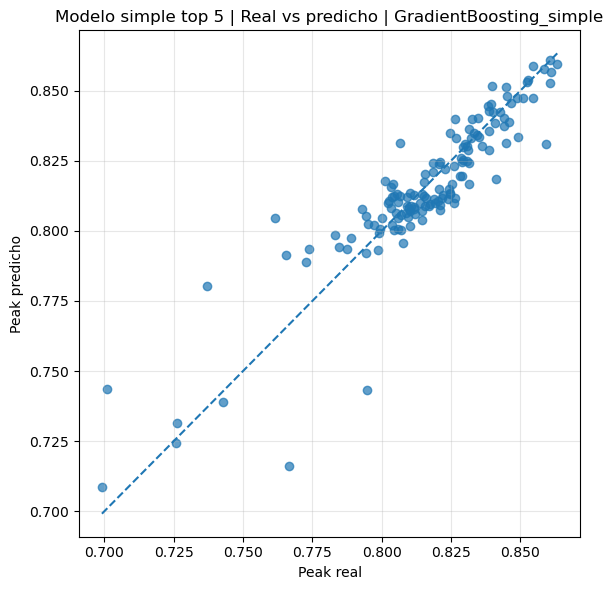

,event_id,event_start,inference_time,HS30_min_target,peak_value,pred_peak_full,pred_peak_simple,abs_error_full,abs_error_simple
120,155,2019-06-28 08:00:00,2019-06-27 19:00:00,0.782111,0.806592,0.830797,0.831162,0.024204,0.024570
570,659,2022-10-02 12:00:00,2022-10-01 19:00:00,0.681801,0.742740,0.733748,0.738885,0.008992,0.003855
39,41,2018-08-22 08:00:00,2018-08-21 19:00:00,0.814787,0.854414,0.850102,0.847236,0.004312,0.007178
294,346,2021-06-29 08:00:00,2021-06-28 19:00:00,0.765164,0.810308,0.810097,0.813330,0.000211,0.003023
666,768,2023-08-01 14:00:00,2023-07-31 19:00:00,0.728398,0.823730,0.820501,0.811236,0.003229,0.012494
437,516,2021-10-11 09:00:00,2021-10-10 19:00:00,0.702300,0.726180,0.738900,0.731371,0.012720,0.005192
65,69,2018-09-26 09:00:00,2018-09-25 19:00:00,0.818335,0.844770,0.846851,0.851132,0.002081,0.006362
499,584,2022-07-21 12:00:00,2022-07-20 19:00:00,0.719762,0.804458,0.811601,0.812502,0.007143,0.008044
78,110,2019-05-17 09:00:00,2019-05-16 19:00:00,0.783661,0.829385,0.826967,0.829903,0.002418,0.000518
653,755,2023-07-19 14:00:00,2023-07-18 19:00:00,0.758311,0.846766,0.842160,0.845733,0.004606,0.001032


In [29]:

pred_full = best_full_model.predict(X_test_full)
pred_simple = best_simple_model.predict(X_test_simple)

plot_df = event_df.loc[X_test_candidates.index, [
    "event_id",
    "event_start",
    "inference_time",
    "HS30_min_target",
    "peak_value"
]].copy()

plot_df["pred_peak_full"] = pred_full
plot_df["pred_peak_simple"] = pred_simple
plot_df["abs_error_full"] = (plot_df["peak_value"] - plot_df["pred_peak_full"]).abs()
plot_df["abs_error_simple"] = (plot_df["peak_value"] - plot_df["pred_peak_simple"]).abs()

plt.figure(figsize=(6, 6))
plt.scatter(plot_df["peak_value"], plot_df["pred_peak_simple"], alpha=0.7)

mn = min(plot_df["peak_value"].min(), plot_df["pred_peak_simple"].min())
mx = max(plot_df["peak_value"].max(), plot_df["pred_peak_simple"].max())

plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Peak real")
plt.ylabel("Peak predicho")
plt.title(f"Modelo simple top 5 | Real vs predicho | {best_simple_label}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(plot_df.head(10))



## 12. Selección automática del modelo final

Por defecto, se elige el modelo simple si su RMSE no empeora más de un 10% respecto al modelo completo LASSO.


In [30]:

MAX_ACCEPTABLE_RMSE_INCREASE = 0.10

if relative_rmse_increase <= MAX_ACCEPTABLE_RMSE_INCREASE:
    final_model_label = best_simple_label
    final_model = best_simple_model
    final_features = simple_features
    final_type = "simple_top4"
else:
    final_model_label = best_full_label
    final_model = best_full_model
    final_features = lasso_selected_features
    final_type = "completo_lasso"

print("Modelo final seleccionado:", final_model_label)
print("Tipo:", final_type)
print("N variables:", len(final_features))
print("Variables finales:")
for f in final_features:
    print("-", f)


Modelo final seleccionado: GradientBoosting_simple
Tipo: simple_top4
N variables: 5
Variables finales:
- HS30_min_target
- HS20_mean_hist_24h_max
- HS30_mean_hist_48h_max
- HS20_mean_hist_24h_min
- HS10_mean_hist_48h_max


In [33]:
def regression_metrics_full(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    bias = np.mean(y_pred - y_true)

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mape,
        "Bias": bias
    }


# OJO: adapta estos nombres si en tu notebook se llaman distinto
# Modelo final: best_simple_model
# Features finales: simple_features

train_pred = best_simple_model.predict(X_train_simple)
test_pred = best_simple_model.predict(X_test_simple)

metrics_final = pd.DataFrame([
    {
        "Split": "Train",
        **regression_metrics_full(y_train, train_pred)
    },
    {
        "Split": "Test",
        **regression_metrics_full(y_test, test_pred)
    }
])

metrics_final

,Split,RMSE,MAE,R2,MAPE,Bias
0,Train,0.007615,0.005593,0.932770,0.694258,5.822848e-17
1,Test,0.012075,0.008028,0.819386,1.001470,-5.568041e-04



## 13. Guardado de artefactos


In [31]:

joblib.dump(final_model, os.path.join(ARTIFACT_DIR, "best_peak_operational_19h_no_std_lasso_selected_model.joblib"))
joblib.dump(best_full_model, os.path.join(ARTIFACT_DIR, "best_peak_operational_19h_no_std_lasso_full_model.joblib"))
joblib.dump(best_simple_model, os.path.join(ARTIFACT_DIR, "best_peak_operational_19h_no_std_lasso_simple_model.joblib"))

metadata = {
    "logic": "Modelo operacional de peak a las 19:00 sin variables std. Modelo completo usa selected=True de LASSO; modelo simple usa top 4.",
    "time_col": TIME_COL,
    "target": "peak_value",
    "include_std": False,
    "candidate_features": candidate_feature_cols,
    "lasso_selected_features": lasso_selected_features,
    "simple_features": simple_features,
    "final_model_label": final_model_label,
    "final_type": final_type,
    "final_features": final_features,
    "full_model_label": best_full_label,
    "simple_model_label": best_simple_label,
    "n_events": int(len(event_df)),
    "n_train": int(len(X_train_candidates)),
    "n_test": int(len(X_test_candidates)),
    "relative_rmse_increase_simple_vs_full": float(relative_rmse_increase),
    "summary_comparison": summary_comparison.to_dict(orient="records")
}

with open(os.path.join(ARTIFACT_DIR, "metadata_peak_operational_19h_no_std_lasso_selected.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)

event_df.to_csv(os.path.join(ARTIFACT_DIR, "event_dataset_peak_operational_19h_no_std_lasso_selected.csv"), index=False)
comparison_df.to_csv(os.path.join(ARTIFACT_DIR, "model_comparison_peak_operational_19h_no_std_lasso_selected.csv"), index=False)
summary_comparison.to_csv(os.path.join(ARTIFACT_DIR, "summary_comparison_peak_operational_19h_no_std_lasso_selected.csv"), index=False)
coef_df.to_csv(os.path.join(ARTIFACT_DIR, "lasso_coefficients_peak_operational_19h_no_std_lasso_selected.csv"), index=False)
plot_df.to_csv(os.path.join(ARTIFACT_DIR, "test_predictions_peak_operational_19h_no_std_lasso_selected.csv"), index=False)

print("Artefactos guardados en:", ARTIFACT_DIR)


Artefactos guardados en: artifacts_peak_operational_19h_no_std_lasso_selected



## 14. Función de inferencia del modelo final


In [32]:

loaded_model = joblib.load(os.path.join(ARTIFACT_DIR, "best_peak_operational_19h_no_std_lasso_selected_model.joblib"))

# Medianas para fallback. En inferencia real lo ideal es calcular todas las variables finales.
if final_type == "simple_top4":
    X_reference = X_train_simple
else:
    X_reference = X_train_full

feature_defaults = X_reference[final_features].median(numeric_only=True).to_dict()

def predict_required_peak_operational(hs30_min_target, context=None):
    """
    Predice el peak post-riego necesario usando el modelo operacional final.

    Parámetros
    ----------
    hs30_min_target : float
        Valor objetivo de HS30 mínimo.
    context : dict, optional
        Diccionario con variables disponibles a las 19:00.

    Returns
    -------
    dict
        Peak predicho, amplitud estimada e inputs usados.
    """
    row = feature_defaults.copy()

    if "HS30_min_target" in row:
        row["HS30_min_target"] = float(hs30_min_target)

    if context is not None:
        for key, value in context.items():
            if key in row:
                row[key] = value

    x_row = pd.DataFrame([row])[final_features]
    pred_peak = float(loaded_model.predict(x_row)[0])

    return {
        "predicted_peak": pred_peak,
        "estimated_amplitude": float(pred_peak - hs30_min_target),
        "inputs_used": x_row.to_dict(orient="records")[0]
    }

example = predict_required_peak_operational(
    hs30_min_target=float(event_df["HS30_min_target"].median()),
    context=None
)

example


{'predicted_peak': 0.79829320225599,
 'estimated_amplitude': 0.04259320225598995,
 'inputs_used': {'HS30_min_target': 0.7557,
  'HS20_mean_hist_24h_max': 0.8411115963100668,
  'HS30_mean_hist_48h_max': 0.8221414572843214,
  'HS20_mean_hist_24h_min': 0.7840053613997839,
  'HS10_mean_hist_48h_max': 0.8428094200028736}}